Изучение стекинга (stacking) и многослойного персептрона (MLP) для задачи классификации на датасете "Титаник".

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.impute import SimpleImputer

from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
sns.set_style('whitegrid')

In [13]:
# Загрузка данных
df = sns.load_dataset('titanic')

print("Исходный размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Исходный размер данных: (891, 15)

Первые 5 строк:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# Предобработка данных
data = df.copy()

# Шаг 1: Удаление дублирующихся и малополезных признаков
columns_to_drop = ['alive', 'deck', 'embark_town', 'who', 'adult_male', 'class']
columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data.drop(columns=columns_to_drop, inplace=True)
print(f"1. Удалены признаки: {columns_to_drop}")

# Шаг 2: Заполнение пропусков
# Age - медианой по полу и классу
data['age'] = data.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.median()))
# Embarked - модой
if 'embarked' in data.columns:
    data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)
print("2. Заполнены пропуски в age и embarked")

# Шаг 3: Кодирование категориальных признаков
# Sex: male->1, female->0
data['sex'] = data['sex'].map({'male': 1, 'female': 0})

# Alone: bool->int
if 'alone' in data.columns:
    data['alone'] = data['alone'].astype(int)

# Embarked: one-hot encoding
if 'embarked' in data.columns:
    data = pd.get_dummies(data, columns=['embarked'], prefix='emb', drop_first=False)
print("3. Выполнено кодирование категориальных признаков")

# Шаг 4: Удаление оставшихся строковых колонок (если есть)
object_cols = data.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    data = data.drop(columns=object_cols)
    print(f"4. Удалены строковые колонки: {object_cols}")
else:
    print("4. Строковые колонки отсутствуют")

# Шаг 5: Проверка результата
print(f"\nИтоговое количество признаков: {data.shape[1]}")
print(f"Типы данных:\n{data.dtypes.value_counts()}")
print(f"\nПроверка пропусков:\n{data.isnull().sum()}")

1. Удалены признаки: ['alive', 'deck', 'embark_town', 'who', 'adult_male', 'class']
2. Заполнены пропуски в age и embarked
3. Выполнено кодирование категориальных признаков
4. Строковые колонки отсутствуют

Итоговое количество признаков: 11
Типы данных:
int64      6
bool       3
float64    2
Name: count, dtype: int64

Проверка пропусков:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
alone       0
emb_C       0
emb_Q       0
emb_S       0
dtype: int64


In [15]:
# Разделение на признаки и целевую переменную
target = 'survived'
X = data.drop(target, axis=1)
y = data[target]

print(f"Признаки X: {X.shape}")
print(f"Целевая переменная y: {y.shape}")
print(f"\nБаланс классов:")
print(f"Погибло (0): {(y==0).sum()} ({((y==0).sum()/len(y))*100:.1f}%)")
print(f"Выжило (1): {(y==1).sum()} ({((y==1).sum()/len(y))*100:.1f}%)")

Признаки X: (891, 10)
Целевая переменная y: (891,)

Баланс классов:
Погибло (0): 549 (61.6%)
Выжило (1): 342 (38.4%)


In [16]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [17]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
# Базовые модели (уровень 0)
base_models = [
    ('random_forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('decision_tree', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Мета-модель (уровень 1) - логистическая регрессия
meta_model = LogisticRegression(random_state=42)

# Создание стекинг-ансамбля
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # 5-кратная кросс-валидация для обучения мета-модели
    stack_method='predict_proba'  # Используем вероятности для мета-признаков
)

print("Создан стекинг-ансамбль из 4 базовых моделей:")
for name, model in base_models:
    print(f"  - {name}: {model.__class__.__name__}")
print(f"  - Мета-модель: {meta_model.__class__.__name__}")

Создан стекинг-ансамбль из 4 базовых моделей:
  - random_forest: RandomForestClassifier
  - gradient_boosting: GradientBoostingClassifier
  - svm: SVC
  - decision_tree: DecisionTreeClassifier
  - Мета-модель: LogisticRegression


In [20]:
# Обучение
stacking_clf.fit(X_train, y_train)

# Предсказания
y_pred_stacking = stacking_clf.predict(X_test)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test)[:, 1]

# Метрики
metrics_stacking = {
    'Model': 'Stacking Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_stacking),
    'Precision': precision_score(y_test, y_pred_stacking),
    'Recall': recall_score(y_test, y_pred_stacking),
    'F1-Score': f1_score(y_test, y_pred_stacking),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_stacking)
}

print(f"\nРезультаты стекинг-ансамбля:")
print(f"  Accuracy:  {metrics_stacking['Accuracy']:.4f}")
print(f"  Precision: {metrics_stacking['Precision']:.4f}")
print(f"  Recall:    {metrics_stacking['Recall']:.4f}")
print(f"  F1-Score:  {metrics_stacking['F1-Score']:.4f}")
print(f"  ROC-AUC:   {metrics_stacking['ROC-AUC']:.4f}")


Результаты стекинг-ансамбля:
  Accuracy:  0.7989
  Precision: 0.8000
  Recall:    0.6377
  F1-Score:  0.7097
  ROC-AUC:   0.8536


In [21]:
# Создание MLP с несколькими скрытыми слоями
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),  # 3 скрытых слоя: 100, 50, 25 нейронов
    activation='relu',                  # Функция активации ReLU
    solver='adam',                      # Оптимизатор Adam
    alpha=0.0001,                       # L2 регуляризация
    batch_size=32,                      # Размер батча
    learning_rate='adaptive',           # Адаптивная скорость обучения
    learning_rate_init=0.001,           # Начальная скорость обучения
    max_iter=200,                       # Максимум итераций
    random_state=42,
    early_stopping=True,                # Ранняя остановка
    validation_fraction=0.1,            # 10% на валидацию
    verbose=False
)

print("Архитектура MLP:")
print(f"  - Входной слой: {X_train.shape[1]} нейронов")
print(f"  - Скрытые слои: 100 → 50 → 25 нейронов")
print(f"  - Выходной слой: 2 нейрона (бинарная классификация)")
print(f"  - Функция активации: ReLU")
print(f"  - Оптимизатор: Adam")
print(f"  - L2 регуляризация: alpha=0.0001")
print(f"  - Early stopping: Да")

Архитектура MLP:
  - Входной слой: 10 нейронов
  - Скрытые слои: 100 → 50 → 25 нейронов
  - Выходной слой: 2 нейрона (бинарная классификация)
  - Функция активации: ReLU
  - Оптимизатор: Adam
  - L2 регуляризация: alpha=0.0001
  - Early stopping: Да


In [22]:
mlp_clf.fit(X_train, y_train)

# Предсказания
y_pred_mlp = mlp_clf.predict(X_test)
y_pred_proba_mlp = mlp_clf.predict_proba(X_test)[:, 1]

# Метрики
metrics_mlp = {
    'Model': 'MLP (Neural Network)',
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_mlp)
}

print(f"\nРезультаты MLP:")
print(f"  Accuracy:  {metrics_mlp['Accuracy']:.4f}")
print(f"  Precision: {metrics_mlp['Precision']:.4f}")
print(f"  Recall:    {metrics_mlp['Recall']:.4f}")
print(f"  F1-Score:  {metrics_mlp['F1-Score']:.4f}")
print(f"  ROC-AUC:   {metrics_mlp['ROC-AUC']:.4f}")

# Количество итераций обучения
print(f"\nФактическое количество итераций: {mlp_clf.n_iter_}")
print(f"Функция потерь: {mlp_clf.loss_:.4f}")


Результаты MLP:
  Accuracy:  0.8101
  Precision: 0.8431
  Recall:    0.6232
  F1-Score:  0.7167
  ROC-AUC:   0.8702

Фактическое количество итераций: 37
Функция потерь: 0.3231


In [23]:
# Создаем DataFrame только для текущих моделей
current_results = pd.DataFrame([metrics_stacking, metrics_mlp])
print("Модели для визуализации:")
print(current_results['Model'].tolist())

Модели для визуализации:
['Stacking Ensemble', 'MLP (Neural Network)']


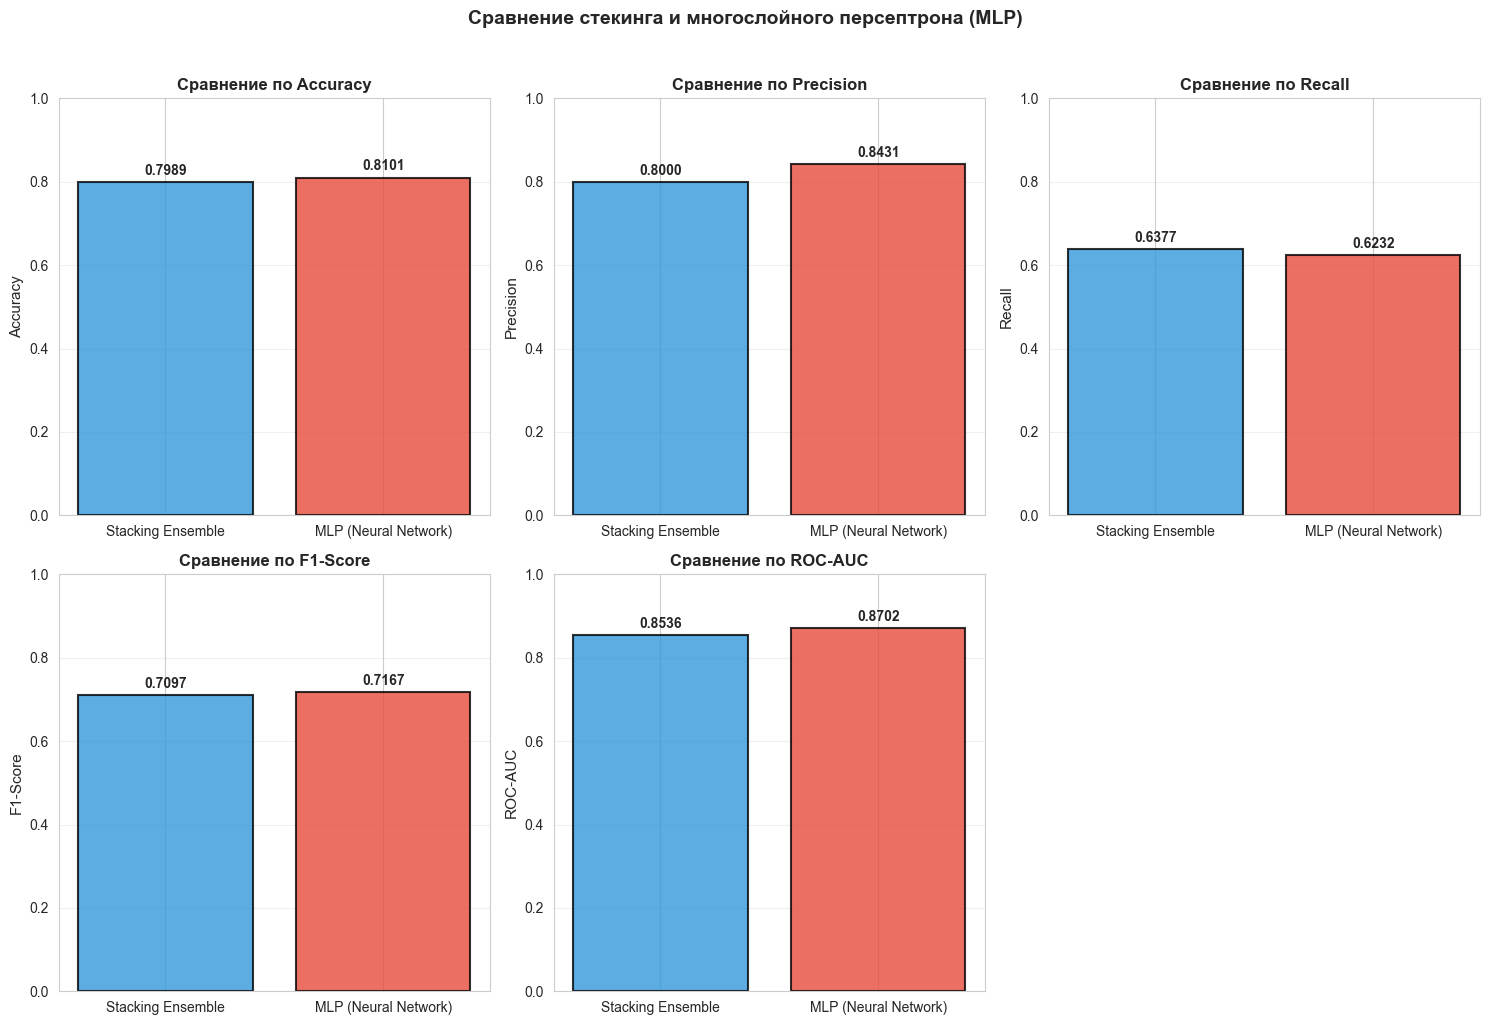

In [ ]:
# Столбчатая диаграмма сравнения
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c']
model_names = current_results['Model'].tolist()

for i, metric in enumerate(metrics_to_plot):
    values = current_results[metric].values
    bars = axes[i].bar(model_names, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[i].set_title(f'Сравнение по {metric}', fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel(metric, fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].set_xticklabels(model_names, rotation=0)
    
    for bar, value in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    

fig.delaxes(axes[5])

plt.suptitle('Сравнение стекинга и многослойного персептрона (MLP)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

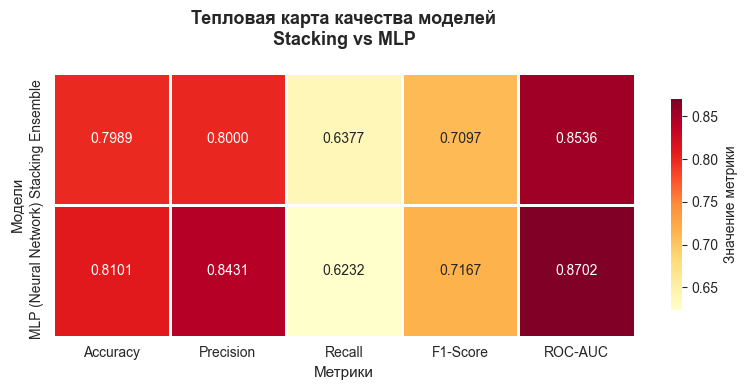

In [ ]:
# Тепловая карта
plt.figure(figsize=(8, 4))
heatmap_data = current_results.set_index('Model')[metrics_to_plot]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', 
            linewidths=2, linecolor='white', 
            cbar_kws={'label': 'Значение метрики', 'shrink': 0.8})
plt.title('Тепловая карта качества моделей\nStacking vs MLP', 
          fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Метрики', fontsize=11)
plt.ylabel('Модели', fontsize=11)
plt.tight_layout()
plt.show()

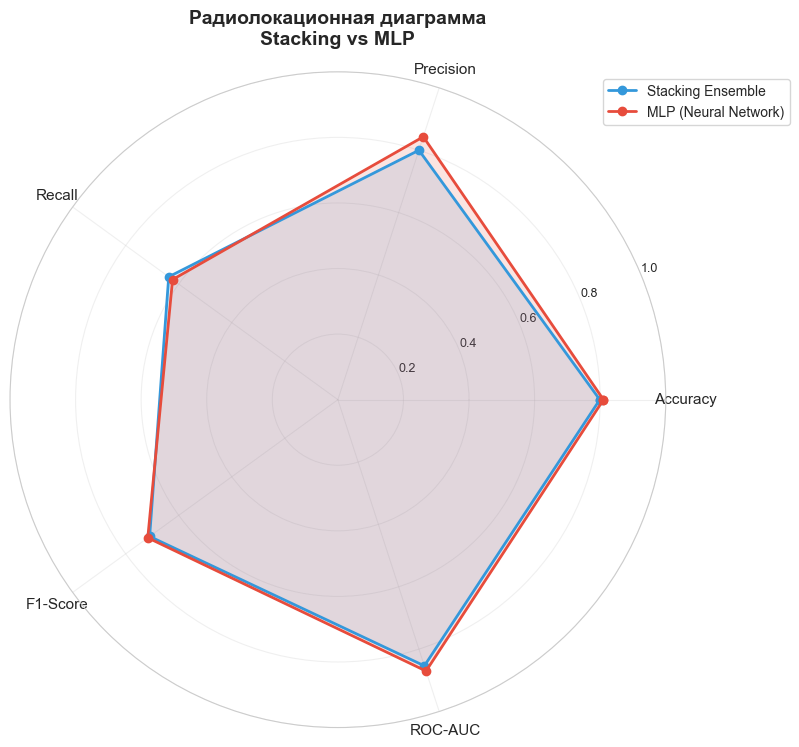

In [ ]:
# Радарная диаграмма
from math import pi

# Подготовка данных
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(metrics_radar)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Замыкаем круг

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Добавляем данные для каждой модели
colors_radar = ['#3498db', '#e74c3c']
for idx, model in enumerate(model_names):
    values = current_results.loc[idx, metrics_radar].values.tolist()
    values += values[:1]  # Замыкаем
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[idx], label=model)
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

# Настройка внешнего вида
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.set_title('Радиолокационная диаграмма\nStacking vs MLP', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

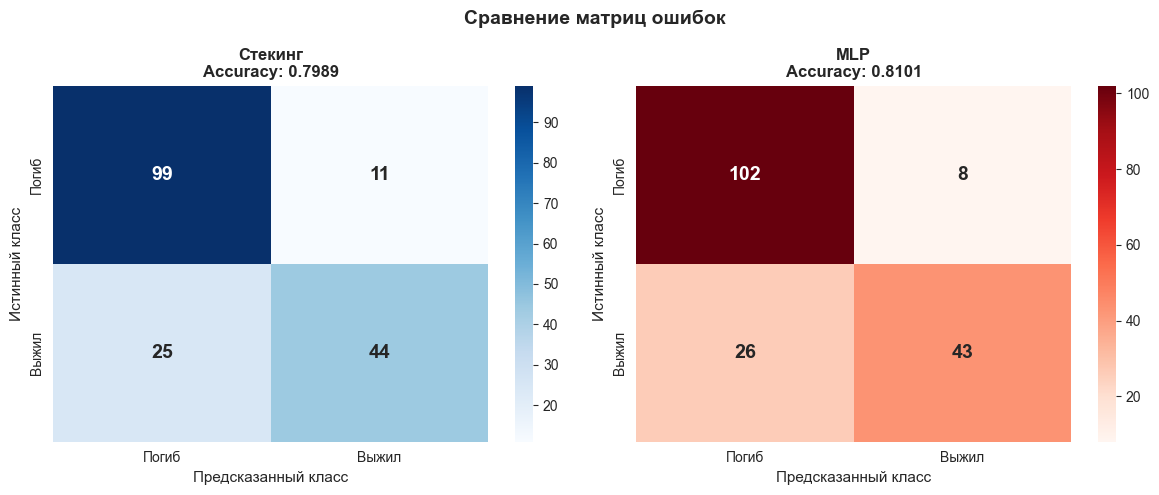

In [32]:
# Сравнение матриц ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Матрица ошибок для стекинга
cm_stack = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Погиб', 'Выжил'], yticklabels=['Погиб', 'Выжил'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Стекинг\nAccuracy: {metrics_stacking["Accuracy"]:.4f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Предсказанный класс', fontsize=11)
axes[0].set_ylabel('Истинный класс', fontsize=11)

# Матрица ошибок для MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Погиб', 'Выжил'], yticklabels=['Погиб', 'Выжил'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'MLP\nAccuracy: {metrics_mlp["Accuracy"]:.4f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Предсказанный класс', fontsize=11)
axes[1].set_ylabel('Истинный класс', fontsize=11)

plt.suptitle('Сравнение матриц ошибок', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [38]:
print("ИТОГОВАЯ СВОДКА ПО ВИЗУАЛИЗАЦИИ")

print("Ключевые наблюдения из визуализаций:")

# Определяем, какая модель лучше по каждой метрике
better_by_metric = {}
for metric in metrics_to_plot:
    if metrics_stacking[metric] > metrics_mlp[metric]:
        better_by_metric[metric] = "Stacking"
    else:
        better_by_metric[metric] = "MLP"

for metric, better in better_by_metric.items():
    diff = abs(metrics_stacking[metric] - metrics_mlp[metric])
    print(f"  • {metric}: лучше у {better} (разница {diff:.4f})")

# Определяем общую лучшую модель
if metrics_stacking['F1-Score'] > metrics_mlp['F1-Score']:
    best_overall = "Stacking"
    best_f1 = metrics_stacking['F1-Score']
else:
    best_overall = "MLP"
    best_f1 = metrics_mlp['F1-Score']

print(f"\nОбщая лучшая модель по F1-Score: {best_overall} ({best_f1:.4f})")

ИТОГОВАЯ СВОДКА ПО ВИЗУАЛИЗАЦИИ
Ключевые наблюдения из визуализаций:
  • Accuracy: лучше у MLP (разница 0.0112)
  • Precision: лучше у MLP (разница 0.0431)
  • Recall: лучше у Stacking (разница 0.0145)
  • F1-Score: лучше у MLP (разница 0.0070)
  • ROC-AUC: лучше у MLP (разница 0.0166)

Общая лучшая модель по F1-Score: MLP (0.7167)
